Here, the in- and outflows of new and old aluminium products (in- and outflows of the in-use process) are calculated for the 12 product categories.

# Packages & Data Import

We use the DynamicStockmodel from ODYM (see ref below) which need to be placed in the same folder as this script.
Pauliuk, S. ODYM - Open Dynamic Material Systems Model; Industrial Ecology, 2018. https://github.com/IndEcol/ODYM.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dynamic_stock_model import DynamicStockModel

In [6]:
#scenarios: need to be changed only in export file name in the end
# '' = reference demand
# 'high demand' = high demand scenario


In [7]:
#importing data file from excel with  the in-use stocks per product category
file = "Global aluminium cycle/Al-Flow model_python_high demand.xlsx"
data = pd.read_excel(file, sheet_name = 'Stocks and Flows', usecols='A:BB', skiprows=1, nrows=151)
data.reset_index(drop=True, inplace=True)
data

,year,In use stock per capita [kg/cap.],In use stock (total) [kt],Stock change total [kt],In-use stock P1 BC,In-use stock P2 TAU,In-use stock P3 TAE,In-use stock P4 TOT,In-use stock P5 PCA,In-use stock P6 POT,...,New Prod. 4 TOT,New Prod. 5 PCA,New Prod. 6 POT,New Prod. 7 ME,New Prod. 8 ECA,New Prod. 9 EOT,New Prod. 10 CD,New Prod. 11 OTN,New Prod. 12 OTD,Total Inflow [kt]
0,1900,NaN,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1901,NaN,1.825818e-01,0.182582,6.027351e-02,0.029941,0.001174,0.020156,0.000978,0.000587,...,0.020156,0.000978,0.000587,0.018787,0.026810,0.004892,0.008219,0.010567,0.000196,0.182582
2,1902,NaN,3.984997e-01,0.215918,1.315519e-01,0.065349,0.002563,0.043993,0.002136,0.001281,...,0.023842,0.002136,0.001281,0.022220,0.031710,0.005788,0.009728,0.012502,0.000427,0.217728
3,1903,NaN,6.538402e-01,0.255341,2.158444e-01,0.107221,0.004205,0.072182,0.003504,0.002102,...,0.028202,0.003504,0.002102,0.026281,0.037505,0.006848,0.011524,0.014792,0.000701,0.259323
4,1904,NaN,9.558013e-01,0.301961,3.155271e-01,0.156739,0.006147,0.105517,0.005122,0.003073,...,0.033361,0.005122,0.003073,0.031085,0.044360,0.008104,0.013668,0.017505,0.001024,0.308561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,2046,356.325902,3.397516e+06,101183.926984,1.121581e+06,557148.875282,21848.975501,375074.079438,18207.479584,10924.487751,...,18443.764108,18207.479584,10924.487751,14414.084134,20570.099233,5961.995810,15011.421360,12877.910951,3641.495917,198833.928470
147,2047,364.933605,3.498512e+06,100996.123865,1.154921e+06,573710.940611,22498.468259,386223.705117,18748.723549,11249.234130,...,18751.573187,18748.723549,11249.234130,14592.077711,20824.110900,6085.033911,15376.729085,13143.673248,3749.744710,202395.596700
148,2048,373.456902,3.599138e+06,100625.797064,1.188140e+06,590212.277107,23145.579494,397332.447987,19287.982912,11572.789747,...,19047.023413,19287.982912,11572.789747,14758.285263,21061.302927,6204.940001,15736.236704,13402.670403,3857.596582,205835.495870
149,2049,381.881884,3.699213e+06,100075.882109,1.221177e+06,606623.434623,23789.154299,408380.482132,19824.295249,11894.577149,...,19329.890668,19824.295249,11894.577149,14912.853280,21281.884368,6321.655789,16089.473300,13654.776505,3964.859050,209152.204316


### Lifetimes 

In [8]:
#Lifetimes and std.dev. of product categories (PCs) as given in Liu et al.(2013)
#PCs: [BC, TAU, TAE, TOT, PCA, POT, ME, ECA, EOT, CD, OTN, OTD]

lifetime_PC = [50, 20, 40, 30, 1, 1, 40, 40, 20, 12, 20, 1]
std_dev_PC = [15, 6, 12, 9, 0.3, 0.3, 12, 12, 6, 3.6, 6, 0.3]

# Product categories

Running stock driven model for each product category

## PC1 - BC (Building and Construction)

In [9]:
#number for counting through the lifetime array
n=0

DSM_PC1 = DynamicStockModel(t=data['year'],
                         s=data['In-use stock P1 BC'],
                         lt={'Type': 'Normal', 
                             'Mean': np.array([lifetime_PC[n]]),
                             'StdDev': np.array([std_dev_PC[n]]) 
                             }
                            )

DSM_PC1.compute_stock_driven_model() 
DSM_PC1.compute_outflow_total()

inflow_PC1 = DSM_PC1.i

outflow_PC1 = DSM_PC1.o

data['New Prod. 1 BC'] = inflow_PC1
data['Outflow P1 BC'] = outflow_PC1

data['Outflow P1 BC']
data

,year,In use stock per capita [kg/cap.],In use stock (total) [kt],Stock change total [kt],In-use stock P1 BC,In-use stock P2 TAU,In-use stock P3 TAE,In-use stock P4 TOT,In-use stock P5 PCA,In-use stock P6 POT,...,New Prod. 4 TOT,New Prod. 5 PCA,New Prod. 6 POT,New Prod. 7 ME,New Prod. 8 ECA,New Prod. 9 EOT,New Prod. 10 CD,New Prod. 11 OTN,New Prod. 12 OTD,Total Inflow [kt]
0,1900,NaN,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1901,NaN,1.825818e-01,0.182582,6.027351e-02,0.029941,0.001174,0.020156,0.000978,0.000587,...,0.020156,0.000978,0.000587,0.018787,0.026810,0.004892,0.008219,0.010567,0.000196,0.182582
2,1902,NaN,3.984997e-01,0.215918,1.315519e-01,0.065349,0.002563,0.043993,0.002136,0.001281,...,0.023842,0.002136,0.001281,0.022220,0.031710,0.005788,0.009728,0.012502,0.000427,0.217728
3,1903,NaN,6.538402e-01,0.255341,2.158444e-01,0.107221,0.004205,0.072182,0.003504,0.002102,...,0.028202,0.003504,0.002102,0.026281,0.037505,0.006848,0.011524,0.014792,0.000701,0.259323
4,1904,NaN,9.558013e-01,0.301961,3.155271e-01,0.156739,0.006147,0.105517,0.005122,0.003073,...,0.033361,0.005122,0.003073,0.031085,0.044360,0.008104,0.013668,0.017505,0.001024,0.308561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,2046,356.325902,3.397516e+06,101183.926984,1.121581e+06,557148.875282,21848.975501,375074.079438,18207.479584,10924.487751,...,18443.764108,18207.479584,10924.487751,14414.084134,20570.099233,5961.995810,15011.421360,12877.910951,3641.495917,198833.928470
147,2047,364.933605,3.498512e+06,100996.123865,1.154921e+06,573710.940611,22498.468259,386223.705117,18748.723549,11249.234130,...,18751.573187,18748.723549,11249.234130,14592.077711,20824.110900,6085.033911,15376.729085,13143.673248,3749.744710,202395.596700
148,2048,373.456902,3.599138e+06,100625.797064,1.188140e+06,590212.277107,23145.579494,397332.447987,19287.982912,11572.789747,...,19047.023413,19287.982912,11572.789747,14758.285263,21061.302927,6204.940001,15736.236704,13402.670403,3857.596582,205835.495870
149,2049,381.881884,3.699213e+06,100075.882109,1.221177e+06,606623.434623,23789.154299,408380.482132,19824.295249,11894.577149,...,19329.890668,19824.295249,11894.577149,14912.853280,21281.884368,6321.655789,16089.473300,13654.776505,3964.859050,209152.204316


## PC2 - TAU (Transportation: Automobiles & Light Trucks)

In [10]:
#number for counting through the lifetime array
n=1

DSM_PC2 = DynamicStockModel(t=data['year'],
                         s=data['In-use stock P2 TAU'],
                         lt={'Type': 'Normal', 
                             'Mean': np.array([lifetime_PC[n]]),
                             'StdDev': np.array([std_dev_PC[n]]) 
                             }
                            )

DSM_PC2.compute_stock_driven_model() 
DSM_PC2.compute_outflow_total()

inflow_PC2 = DSM_PC2.i

outflow_PC2 = DSM_PC2.o

data['New Prod. 2 TAU'] = inflow_PC2
data['Outflow P2 TAU'] = outflow_PC2
data['Outflow P2 TAU']
data

,year,In use stock per capita [kg/cap.],In use stock (total) [kt],Stock change total [kt],In-use stock P1 BC,In-use stock P2 TAU,In-use stock P3 TAE,In-use stock P4 TOT,In-use stock P5 PCA,In-use stock P6 POT,...,New Prod. 4 TOT,New Prod. 5 PCA,New Prod. 6 POT,New Prod. 7 ME,New Prod. 8 ECA,New Prod. 9 EOT,New Prod. 10 CD,New Prod. 11 OTN,New Prod. 12 OTD,Total Inflow [kt]
0,1900,NaN,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1901,NaN,1.825818e-01,0.182582,6.027351e-02,0.029941,0.001174,0.020156,0.000978,0.000587,...,0.020156,0.000978,0.000587,0.018787,0.026810,0.004892,0.008219,0.010567,0.000196,0.182582
2,1902,NaN,3.984997e-01,0.215918,1.315519e-01,0.065349,0.002563,0.043993,0.002136,0.001281,...,0.023842,0.002136,0.001281,0.022220,0.031710,0.005788,0.009728,0.012502,0.000427,0.217728
3,1903,NaN,6.538402e-01,0.255341,2.158444e-01,0.107221,0.004205,0.072182,0.003504,0.002102,...,0.028202,0.003504,0.002102,0.026281,0.037505,0.006848,0.011524,0.014792,0.000701,0.259323
4,1904,NaN,9.558013e-01,0.301961,3.155271e-01,0.156739,0.006147,0.105517,0.005122,0.003073,...,0.033361,0.005122,0.003073,0.031085,0.044360,0.008104,0.013668,0.017505,0.001024,0.308561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,2046,356.325902,3.397516e+06,101183.926984,1.121581e+06,557148.875282,21848.975501,375074.079438,18207.479584,10924.487751,...,18443.764108,18207.479584,10924.487751,14414.084134,20570.099233,5961.995810,15011.421360,12877.910951,3641.495917,198833.928470
147,2047,364.933605,3.498512e+06,100996.123865,1.154921e+06,573710.940611,22498.468259,386223.705117,18748.723549,11249.234130,...,18751.573187,18748.723549,11249.234130,14592.077711,20824.110900,6085.033911,15376.729085,13143.673248,3749.744710,202395.596700
148,2048,373.456902,3.599138e+06,100625.797064,1.188140e+06,590212.277107,23145.579494,397332.447987,19287.982912,11572.789747,...,19047.023413,19287.982912,11572.789747,14758.285263,21061.302927,6204.940001,15736.236704,13402.670403,3857.596582,205835.495870
149,2049,381.881884,3.699213e+06,100075.882109,1.221177e+06,606623.434623,23789.154299,408380.482132,19824.295249,11894.577149,...,19329.890668,19824.295249,11894.577149,14912.853280,21281.884368,6321.655789,16089.473300,13654.776505,3964.859050,209152.204316


## PC3 - TAE (Transportation: Aerospace)

In [11]:
#number for counting through the lifetime array (PC_i-1)
n=2

DSM_PC3 = DynamicStockModel(t=data['year'],
                         s=data['In-use stock P3 TAE'],
                         lt={'Type': 'Normal', 
                             'Mean': np.array([lifetime_PC[n]]),
                             'StdDev': np.array([std_dev_PC[n]]) 
                             }
                            )

DSM_PC3.compute_stock_driven_model() 
DSM_PC3.compute_outflow_total()

inflow_PC3 = DSM_PC3.i

outflow_PC3 = DSM_PC3.o

data['New Prod. 3 TAE'] = inflow_PC3
data['Outflow P3 TAE'] = outflow_PC3
data['Outflow P3 TAE']

0      0.000000e+00
1      5.040015e-07
2      7.699063e-07
3      1.138438e-06
4      1.643086e-06
           ...     
146    2.435713e+02
147    2.556466e+02
148    2.681600e+02
149    2.811027e+02
150    2.944635e+02
Name: Outflow P3 TAE, Length: 151, dtype: float64

## PC4 - TOT (Transportation: Others)

In [12]:
#number for counting through the lifetime array
n=3

DSM_PC4 = DynamicStockModel(t=data['year'],
                         s=data['In-use stock P4 TOT'],
                         lt={'Type': 'Normal', 
                             'Mean': np.array([lifetime_PC[n]]),
                             'StdDev': np.array([std_dev_PC[n]]) 
                             }
                            )

DSM_PC4.compute_stock_driven_model() 
DSM_PC4.compute_outflow_total()

data['New Prod. 4 TOT'] = DSM_PC4.i
data['Outflow P4 TOT'] = DSM_PC4.o

data
data['Outflow P4 TOT']

0         0.000000
1         0.000009
2         0.000014
3         0.000023
4         0.000036
          ...     
146    7069.979941
147    7391.698695
148    7721.315418
149    8058.299850
150    8402.086365
Name: Outflow P4 TOT, Length: 151, dtype: float64

## PC5 - PCA (Packaging: Cans)

In [13]:
#number for counting through the lifetime array
n=4

#problem: std_dev lower than 1 --> huge outflows/inflows
DSM_PC5 = DynamicStockModel(t=data['year'],
                         s=data['In-use stock P5 PCA'],
                         lt={'Type': 'Fixed', 
                             'Mean': np.array([lifetime_PC[n]])
                             }
                            )

'''DSM_PC5 = DynamicStockModel(t=data['year'],
                         s=data['In-use stock P5 PCA'],
                         lt={'Type': 'Normal', 
                             'Mean': np.array([lifetime_PC[n]]),
                             'StdDev': np.array([std_dev_PC[n]]) 
                             }
                            )'''
            
DSM_PC5.compute_stock_driven_model() 
DSM_PC5.compute_outflow_total()

data['New Prod. 5 PCA'] = DSM_PC5.i
data['Outflow P5 PCA'] = DSM_PC5.o
data['Outflow P5 PCA']
data

,year,In use stock per capita [kg/cap.],In use stock (total) [kt],Stock change total [kt],In-use stock P1 BC,In-use stock P2 TAU,In-use stock P3 TAE,In-use stock P4 TOT,In-use stock P5 PCA,In-use stock P6 POT,...,New Prod. 4 TOT,New Prod. 5 PCA,New Prod. 6 POT,New Prod. 7 ME,New Prod. 8 ECA,New Prod. 9 EOT,New Prod. 10 CD,New Prod. 11 OTN,New Prod. 12 OTD,Total Inflow [kt]
0,1900,NaN,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1901,NaN,1.825818e-01,0.182582,6.027351e-02,0.029941,0.001174,0.020156,0.000978,0.000587,...,0.020165,0.000978,0.000587,0.018787,0.026810,0.004892,0.008219,0.010567,0.000196,0.182582
2,1902,NaN,3.984997e-01,0.215918,1.315519e-01,0.065349,0.002563,0.043993,0.002136,0.001281,...,0.023851,0.002136,0.001281,0.022220,0.031710,0.005788,0.009728,0.012502,0.000427,0.217728
3,1903,NaN,6.538402e-01,0.255341,2.158444e-01,0.107221,0.004205,0.072182,0.003504,0.002102,...,0.028212,0.003504,0.002102,0.026281,0.037505,0.006848,0.011524,0.014792,0.000701,0.259323
4,1904,NaN,9.558013e-01,0.301961,3.155271e-01,0.156739,0.006147,0.105517,0.005122,0.003073,...,0.033371,0.005122,0.003073,0.031085,0.044360,0.008104,0.013668,0.017505,0.001024,0.308561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,2046,356.325902,3.397516e+06,101183.926984,1.121581e+06,557148.875282,21848.975501,375074.079438,18207.479584,10924.487751,...,18240.338440,18207.479584,10924.487751,14414.084134,20570.099233,5961.995810,15011.421360,12877.910951,3641.495917,198833.928470
147,2047,364.933605,3.498512e+06,100996.123865,1.154921e+06,573710.940611,22498.468259,386223.705117,18748.723549,11249.234130,...,18541.324374,18748.723549,11249.234130,14592.077711,20824.110900,6085.033911,15376.729085,13143.673248,3749.744710,202395.596700
148,2048,373.456902,3.599138e+06,100625.797064,1.188140e+06,590212.277107,23145.579494,397332.447987,19287.982912,11572.789747,...,18830.058288,19287.982912,11572.789747,14758.285263,21061.302927,6204.940001,15736.236704,13402.670403,3857.596582,205835.495870
149,2049,381.881884,3.699213e+06,100075.882109,1.221177e+06,606623.434623,23789.154299,408380.482132,19824.295249,11894.577149,...,19106.333995,19824.295249,11894.577149,14912.853280,21281.884368,6321.655789,16089.473300,13654.776505,3964.859050,209152.204316


## PC6 - POT (Packaging: Others)

In [14]:
#number for counting through the lifetime array
#same problem as for PCA
n=5

DSM_PC6 = DynamicStockModel(t=data['year'],
                         s=data['In-use stock P6 POT'],
                         lt={'Type': 'Fixed', 
                             'Mean': np.array([lifetime_PC[n]]),
                             'StdDev': np.array([std_dev_PC[n]]) 
                             }
                            )

DSM_PC6.compute_stock_driven_model() 
DSM_PC6.compute_outflow_total()

data['New Prod. 6 POT'] = DSM_PC6.i
data['Outflow P6 POT'] = DSM_PC6.o

data['Outflow P6 POT']

0          0.000000
1          0.000000
2          0.000587
3          0.001281
4          0.002102
           ...     
146    10599.137503
147    10924.487751
148    11249.234130
149    11572.789747
150    11894.577149
Name: Outflow P6 POT, Length: 151, dtype: float64

## PC7 - ME (Machinery & Equipment)

In [15]:
#number for counting through the lifetime array
n=6

DSM_PC7 = DynamicStockModel(t=data['year'],
                         s=data['In-use stock P7 ME'],
                         lt={'Type': 'Normal', 
                             'Mean': np.array([lifetime_PC[n]]),
                             'StdDev': np.array([std_dev_PC[n]]) 
                             }
                            )

DSM_PC7.compute_stock_driven_model() 
DSM_PC7.compute_outflow_total()

data['New Prod. 7 ME'] = DSM_PC7.i
data['Outflow P7 ME'] = DSM_PC7.o

data['Outflow P7 ME']

0         0.000000
1         0.000008
2         0.000012
3         0.000018
4         0.000026
          ...     
146    3897.141568
147    4090.345765
148    4290.560781
149    4497.643115
150    4711.415373
Name: Outflow P7 ME, Length: 151, dtype: float64

## PC8 - ECA (Electrical: Cables)

In [16]:
#number for counting through the lifetiECA array
n=7

DSM_PC8 = DynamicStockModel(t=data['year'],
                         s=data['In-use stock P8 ECA'],
                         lt={'Type': 'Normal', 
                             'Mean': np.array([lifetime_PC[n]]),
                             'StdDev': np.array([std_dev_PC[n]]) 
                             }
                            )

DSM_PC8.compute_stock_driven_model() 
DSM_PC8.compute_outflow_total()

data['New Prod. 8 ECA'] = DSM_PC8.i
data['Outflow P8 ECA'] = DSM_PC8.o

data['Outflow P8 ECA']

0         0.000000
1         0.000012
2         0.000018
3         0.000026
4         0.000038
          ...     
146    5561.545779
147    5837.264268
148    6122.987781
149    6418.511529
150    6723.582355
Name: Outflow P8 ECA, Length: 151, dtype: float64

## PC9 - EOT (Electrical: Others)

In [17]:
#number for counting through the lifetiEOT array
n=8

DSM_PC9 = DynamicStockModel(t=data['year'],
                         s=data['In-use stock P9 EOT'],
                         lt={'Type': 'Normal', 
                             'Mean': np.array([lifetime_PC[n]]),
                             'StdDev': np.array([std_dev_PC[n]]) 
                             }
                            )

DSM_PC9.compute_stock_driven_model() 
DSM_PC9.compute_outflow_total()

data['New Prod. 9 EOT'] = DSM_PC9.i
data['Outflow P9 EOT'] = DSM_PC9.o

data['Outflow P9 EOT']

0         0.000000
1         0.000002
2         0.000004
3         0.000008
4         0.000014
          ...     
146    3142.698047
147    3267.488266
148    3394.024453
149    3522.179008
150    3651.809862
Name: Outflow P9 EOT, Length: 151, dtype: float64

## PC10 - CD (Consumer Durables)

In [18]:
#number for counting through the lifetiCD array
n=9

DSM_PC10 = DynamicStockModel(t=data['year'],
                         s=data['In-use stock P10 CD'],
                         lt={'Type': 'Normal', 
                             'Mean': np.array([lifetime_PC[n]]),
                             'StdDev': np.array([std_dev_PC[n]]) 
                             }
                            )

DSM_PC10.compute_stock_driven_model() 
DSM_PC10.compute_outflow_total()

data['New Prod. 10 CD'] = DSM_PC10.i
data['Outflow P10 CD'] = DSM_PC10.o

data['Outflow P10 CD']

0          0.000000
1          0.000004
2          0.000010
3          0.000025
4          0.000058
           ...     
146     9966.286443
147    10325.886265
148    10687.953460
149    11051.858358
150    11417.022324
Name: Outflow P10 CD, Length: 151, dtype: float64

## PC11 - OTN (Other Uses: non-Destructive Use)

In [19]:
#number for counting through the lifetiOTN array
n=10

DSM_PC11 = DynamicStockModel(t=data['year'],
                         s=data['In-use stock P11 OTN'],
                         lt={'Type': 'Normal', 
                             'Mean': np.array([lifetime_PC[n]]),
                             'StdDev': np.array([std_dev_PC[n]]) 
                             }
                            )

DSM_PC11.compute_stock_driven_model() 
DSM_PC11.compute_outflow_total()

data['New Prod. 11 OTN'] = DSM_PC11.i
data['Outflow P11 OTN'] = DSM_PC11.o

data['Outflow P11 OTN']

0         0.000000
1         0.000005
2         0.000009
3         0.000017
4         0.000030
          ...     
146    6788.227782
147    7057.774655
148    7331.092819
149    7607.906658
150    7887.909303
Name: Outflow P11 OTN, Length: 151, dtype: float64

## PC12 - OTD (Destructive Uses)

In [20]:
#number for counting through the lifetiOTD array
#same problem as for PCA
n=11

DSM_PC12 = DynamicStockModel(t=data['year'],
                         s=data['In-use stock P12 OTD'],
                         lt={'Type': 'Fixed', 
                             'Mean': np.array([lifetime_PC[n]]),
                             'StdDev': np.array([std_dev_PC[n]]) 
                             }
                            )

DSM_PC12.compute_stock_driven_model() 
DSM_PC12.compute_outflow_total()

data['New Prod. 12 OTD'] = DSM_PC12.i
data['Outflow P12 OTD'] = DSM_PC12.o

data['Outflow P12 OTD']
data

,year,In use stock per capita [kg/cap.],In use stock (total) [kt],Stock change total [kt],In-use stock P1 BC,In-use stock P2 TAU,In-use stock P3 TAE,In-use stock P4 TOT,In-use stock P5 PCA,In-use stock P6 POT,...,New Prod. 4 TOT,New Prod. 5 PCA,New Prod. 6 POT,New Prod. 7 ME,New Prod. 8 ECA,New Prod. 9 EOT,New Prod. 10 CD,New Prod. 11 OTN,New Prod. 12 OTD,Total Inflow [kt]
0,1900,NaN,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1901,NaN,1.825818e-01,0.182582,6.027351e-02,0.029941,0.001174,0.020156,0.000978,0.000587,...,0.020165,0.000978,0.000587,0.018795,0.026821,0.004894,0.008223,0.010572,0.000196,0.182582
2,1902,NaN,3.984997e-01,0.215918,1.315519e-01,0.065349,0.002563,0.043993,0.002136,0.001281,...,0.023851,0.002136,0.001281,0.022229,0.031723,0.005790,0.009730,0.012506,0.000427,0.217728
3,1903,NaN,6.538402e-01,0.255341,2.158444e-01,0.107221,0.004205,0.072182,0.003504,0.002102,...,0.028212,0.003504,0.002102,0.026291,0.037520,0.006850,0.011519,0.014795,0.000701,0.259323
4,1904,NaN,9.558013e-01,0.301961,3.155271e-01,0.156739,0.006147,0.105517,0.005122,0.003073,...,0.033371,0.005122,0.003073,0.031096,0.044377,0.008105,0.013651,0.017507,0.001024,0.308561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,2046,356.325902,3.397516e+06,101183.926984,1.121581e+06,557148.875282,21848.975501,375074.079438,18207.479584,10924.487751,...,18240.338440,18207.479584,10924.487751,14308.349489,20419.207083,5853.950110,14521.189909,12644.532237,3641.495917,198833.928470
147,2047,364.933605,3.498512e+06,100996.123865,1.154921e+06,573710.940611,22498.468259,386223.705117,18748.723549,11249.234130,...,18541.324374,18748.723549,11249.234130,14482.229892,20667.348909,5973.708091,14872.335571,12903.209477,3749.744710,202395.596700
148,2048,373.456902,3.599138e+06,100625.797064,1.188140e+06,590212.277107,23145.579494,397332.447987,19287.982912,11572.789747,...,18830.058288,19287.982912,11572.789747,14644.340543,20898.694317,6090.321267,15217.732106,13155.093936,3857.596582,205835.495870
149,2049,381.881884,3.699213e+06,100075.882109,1.221177e+06,606623.434623,23789.154299,408380.482132,19824.295249,11894.577149,...,19106.333995,19824.295249,11894.577149,14794.839988,21113.469566,6203.740694,15556.881990,13400.079899,3964.859050,209152.204316


In [21]:
data.iloc[:,41:53]

,New Prod. 1 BC,New Prod. 2 TAU,New Prod. 3 TAE,New Prod. 4 TOT,New Prod. 5 PCA,New Prod. 6 POT,New Prod. 7 ME,New Prod. 8 ECA,New Prod. 9 EOT,New Prod. 10 CD,New Prod. 11 OTN,New Prod. 12 OTD
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.060299,0.029954,0.001175,0.020165,0.000978,0.000587,0.018795,0.026821,0.004894,0.008223,0.010572,0.000196
2,0.071316,0.035433,0.001389,0.023851,0.002136,0.001281,0.022229,0.031723,0.005790,0.009730,0.012506,0.000427
3,0.084346,0.041920,0.001643,0.028212,0.003504,0.002102,0.026291,0.037520,0.006850,0.011519,0.014795,0.000701
4,0.099756,0.049602,0.001944,0.033371,0.005122,0.003073,0.031096,0.044377,0.008105,0.013651,0.017507,0.001024
...,...,...,...,...,...,...,...,...,...,...,...,...
146,41201.221111,35826.174672,894.271843,18240.338440,18207.479584,10924.487751,14308.349489,20419.207083,5853.950110,14521.189909,12644.532237,3641.495917
147,41520.474089,36559.093517,905.139368,18541.324374,18748.723549,11249.234130,14482.229892,20667.348909,5973.708091,14872.335571,12903.209477,3749.744710
148,41797.913230,37272.766151,915.271284,18830.058288,19287.982912,11572.789747,14644.340543,20898.694317,6090.321267,15217.732106,13155.093936,3857.596582
149,42034.755095,37966.893048,924.677499,19106.333995,19824.295249,11894.577149,14794.839988,21113.469566,6203.740694,15556.881990,13400.079899,3964.859050


# Figures

Some figures for in- and outflows of the product categories

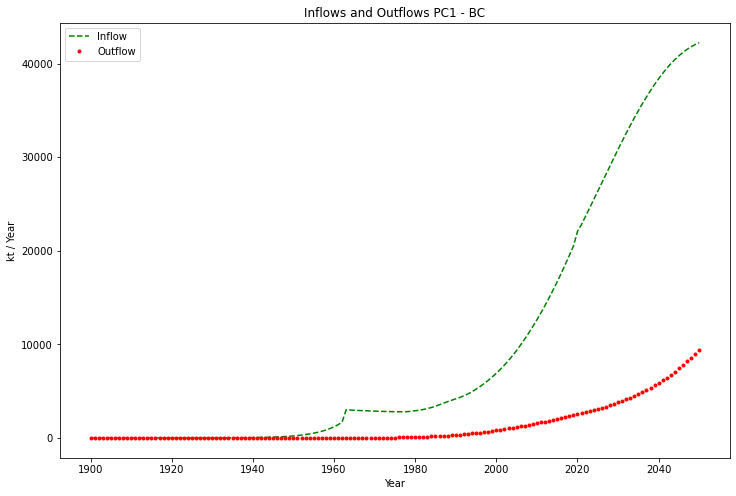

In [22]:
# Inflows and Outflows - PC1 BC
plt.figure(figsize=(12, 8))
plt.plot(DSM_PC1.t, DSM_PC1.i, 'g--', label='Inflow')
plt.plot(DSM_PC1.t, DSM_PC1.o, 'r.', label='Outflow')
plt.title('Inflows and Outflows PC1 - BC')
plt.xlabel('Year')
plt.ylabel('kt / Year')
plt.legend(loc='best')
#plt.savefig('Python exports/inflows_outflows_PC1_regression_exp before 1962')

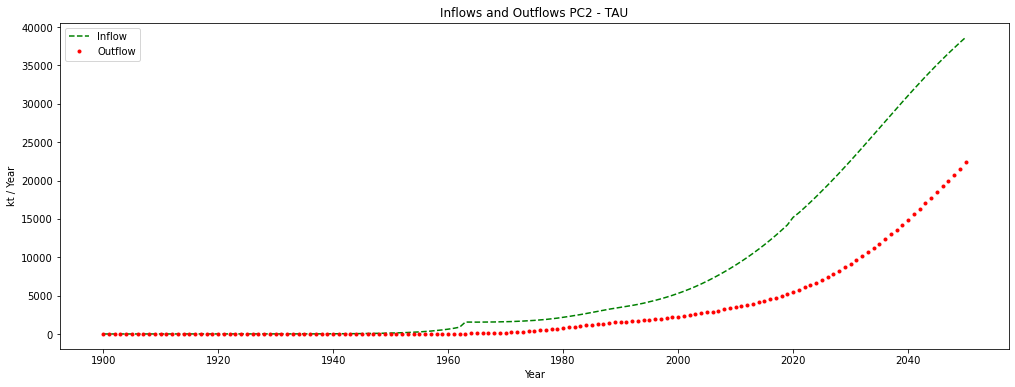

In [23]:
# Inflows and Outflows - PC2 TAU
plt.figure(figsize=(17, 6))
plt.plot(DSM_PC2.t, DSM_PC2.i, 'g--', label='Inflow')
plt.plot(DSM_PC2.t, DSM_PC2.o, 'r.', label='Outflow')
plt.title('Inflows and Outflows PC2 - TAU')
plt.xlabel('Year')
plt.ylabel('kt / Year')
plt.legend(loc='best')
#plt.savefig('inflows_outflows_PC2')

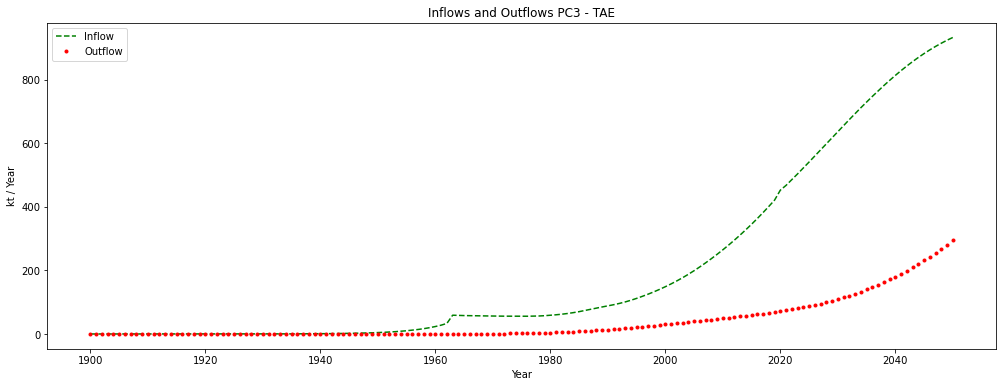

In [24]:
# Inflows and Outflows - PC3 TAE
plt.figure(figsize=(17, 6))
plt.plot(DSM_PC3.t, DSM_PC3.i, 'g--', label='Inflow')
plt.plot(DSM_PC3.t, DSM_PC3.o, 'r.', label='Outflow')
plt.title('Inflows and Outflows PC3 - TAE')
plt.xlabel('Year')
plt.ylabel('kt / Year')
plt.legend(loc='best')
#plt.savefig('inflows_outflows_PC3')

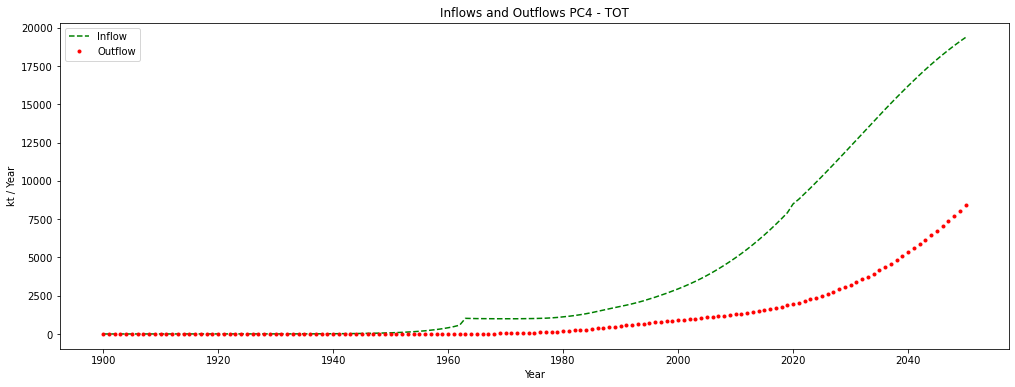

In [25]:
# Inflows and Outflows - PC4 TOT
plt.figure(figsize=(17, 6))
plt.plot(DSM_PC4.t, DSM_PC4.i, 'g--', label='Inflow')
plt.plot(DSM_PC4.t, DSM_PC4.o, 'r.', label='Outflow')
plt.title('Inflows and Outflows PC4 - TOT')
plt.xlabel('Year')
plt.ylabel('kt / Year')
plt.legend(loc='best')
#plt.savefig('inflows_outflows_PC4')

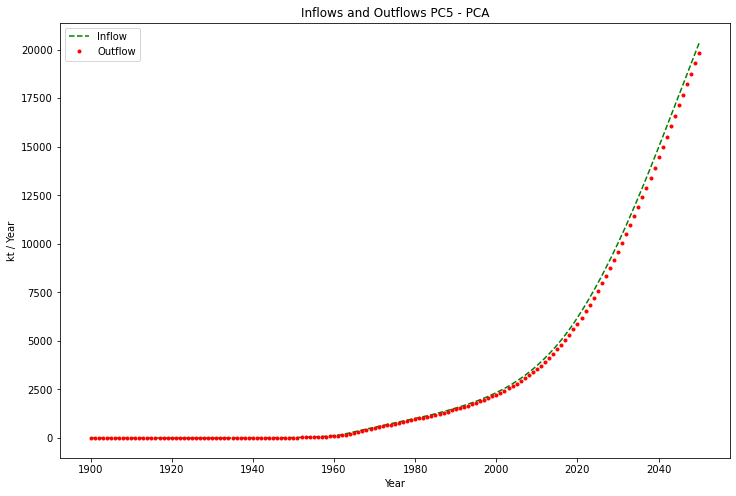

In [26]:
# Inflows and Outflows - PC5 PCA
plt.figure(figsize=(12, 8))
plt.plot(DSM_PC5.t, DSM_PC5.i, 'g--', label='Inflow')
plt.plot(DSM_PC5.t, DSM_PC5.o, 'r.', label='Outflow')
plt.title('Inflows and Outflows PC5 - PCA')
plt.xlabel('Year')
plt.ylabel('kt / Year')
plt.legend(loc='best')
plt.savefig('inflows_outflows_PC5')

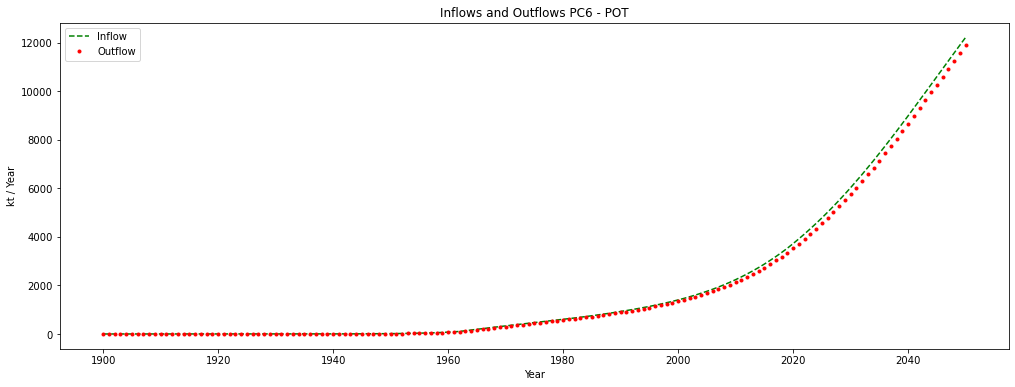

In [27]:
# Inflows and Outflows - PC6 POT
plt.figure(figsize=(17, 6))
plt.plot(DSM_PC6.t, DSM_PC6.i, 'g--', label='Inflow')
plt.plot(DSM_PC6.t, DSM_PC6.o, 'r.', label='Outflow')
plt.title('Inflows and Outflows PC6 - POT')
plt.xlabel('Year')
plt.ylabel('kt / Year')
plt.legend(loc='best')
#plt.savefig('inflows_outflows_PC6')

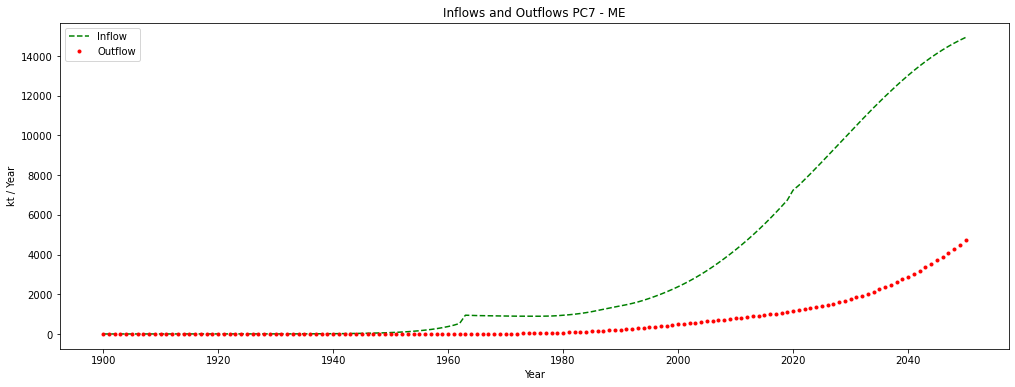

In [28]:
# Inflows and Outflows - PC7 ME
plt.figure(figsize=(17, 6))
plt.plot(DSM_PC7.t, DSM_PC7.i, 'g--', label='Inflow')
plt.plot(DSM_PC7.t, DSM_PC7.o, 'r.', label='Outflow')
plt.title('Inflows and Outflows PC7 - ME')
plt.xlabel('Year')
plt.ylabel('kt / Year')
plt.legend(loc='best')
#plt.savefig('inflows_outflows_PC7')

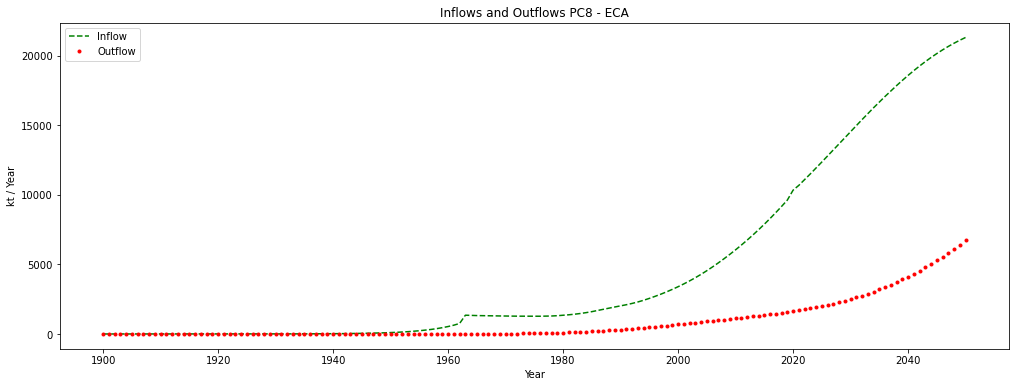

In [29]:
# Inflows and Outflows - PC8 ECA
plt.figure(figsize=(17, 6))
plt.plot(DSM_PC8.t, DSM_PC8.i, 'g--', label='Inflow')
plt.plot(DSM_PC8.t, DSM_PC8.o, 'r.', label='Outflow')
plt.title('Inflows and Outflows PC8 - ECA')
plt.xlabel('Year')
plt.ylabel('kt / Year')
plt.legend(loc='best')
#plt.savefig('inflows_outflows_PC8')

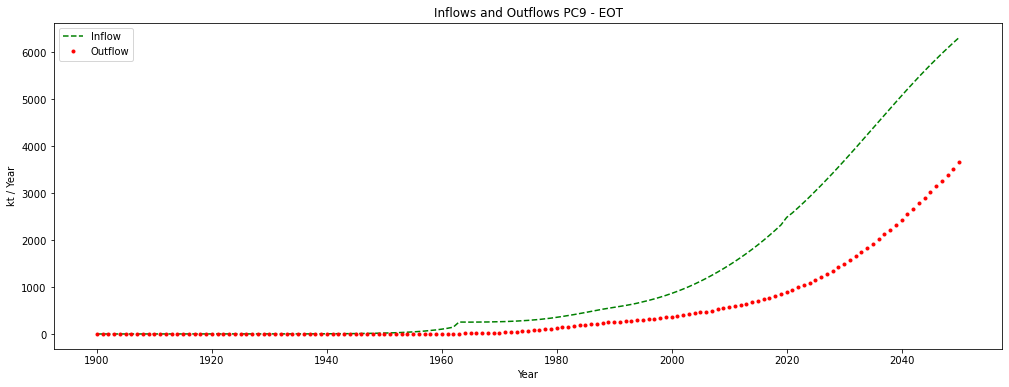

In [30]:
# Inflows and Outflows - PC9 EOT
plt.figure(figsize=(17, 6))
plt.plot(DSM_PC9.t, DSM_PC9.i, 'g--', label='Inflow')
plt.plot(DSM_PC9.t, DSM_PC9.o, 'r.', label='Outflow')
plt.title('Inflows and Outflows PC9 - EOT')
plt.xlabel('Year')
plt.ylabel('kt / Year')
plt.legend(loc='best')
#plt.savefig('inflows_outflows_PC9')

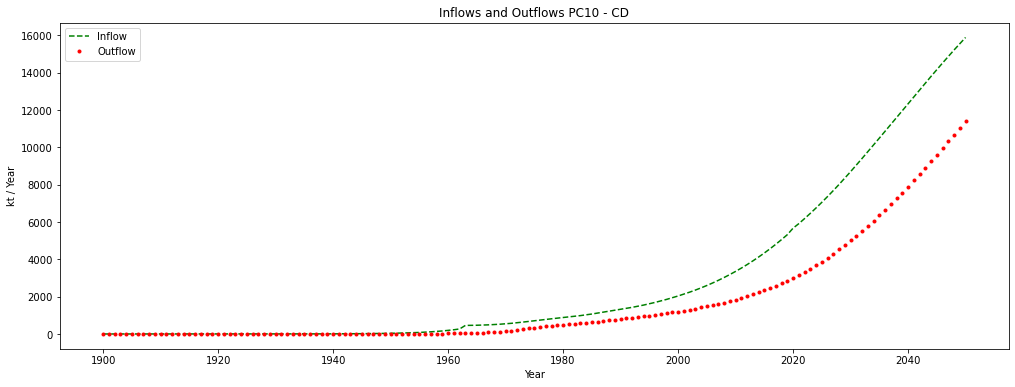

In [31]:
# Inflows and Outflows - PC10 CD
plt.figure(figsize=(17, 6))
plt.plot(DSM_PC10.t, DSM_PC10.i, 'g--', label='Inflow')
plt.plot(DSM_PC10.t, DSM_PC10.o, 'r.', label='Outflow')
plt.title('Inflows and Outflows PC10 - CD')
plt.xlabel('Year')
plt.ylabel('kt / Year')
plt.legend(loc='best')
#plt.savefig('inflows_outflows_PC10')

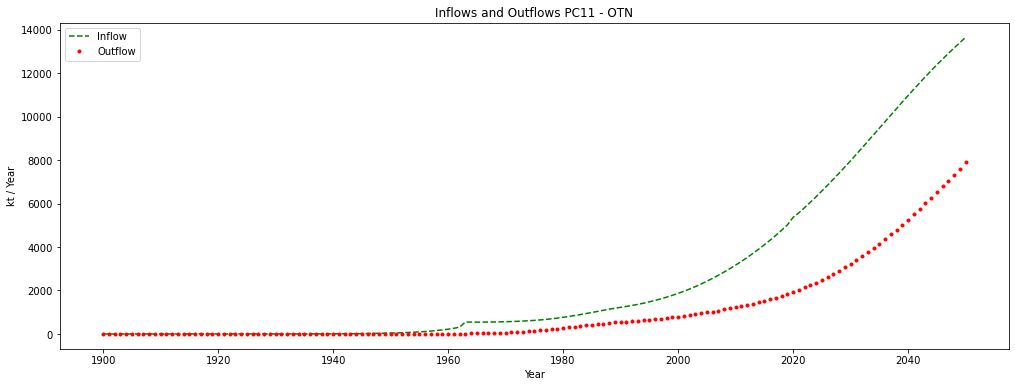

In [32]:
# Inflows and Outflows - PC11 OTN
plt.figure(figsize=(17, 6))
plt.plot(DSM_PC11.t, DSM_PC11.i, 'g--', label='Inflow')
plt.plot(DSM_PC11.t, DSM_PC11.o, 'r.', label='Outflow')
plt.title('Inflows and Outflows PC11 - OTN')
plt.xlabel('Year')
plt.ylabel('kt / Year')
plt.legend(loc='best')
#plt.savefig('inflows_outflows_PC11')

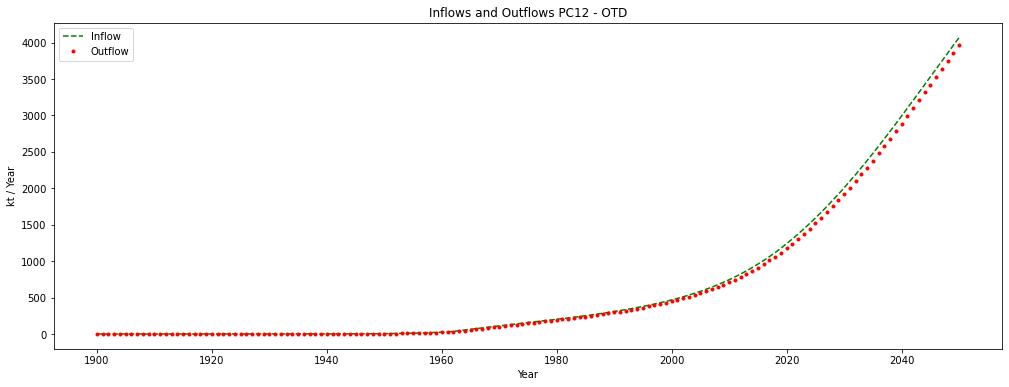

In [33]:
# Inflows and Outflows - PC12 OTD
plt.figure(figsize=(17, 6))
plt.plot(DSM_PC12.t, DSM_PC12.i, 'g--', label='Inflow')
plt.plot(DSM_PC12.t, DSM_PC12.o, 'r.', label='Outflow')
plt.title('Inflows and Outflows PC12 - OTD')
plt.xlabel('Year')
plt.ylabel('kt / Year')
plt.legend(loc='best')
#plt.savefig('inflows_outflows_PC12')

# Export

Exporting the filled data file to write it in the excel file again.

In [34]:
#separating Inflows
data_inflows = data.iloc[:,41:53]

#separating Outflows
data_outflows = data.iloc[:,28:40]
data_outflows

,Outflow P1 BC,Outflow P2 TAU,Outflow P3 TAE,Outflow P4 TOT,Outflow P5 PCA,Outflow P6 POT,Outflow P7 ME,Outflow P8 ECA,Outflow P9 EOT,Outflow P10 CD,Outflow P11 OTN,Outflow P12 OTD
0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000026,0.000013,5.040015e-07,0.000009,0.000000,0.000000,0.000008,0.000012,0.000002,0.000004,0.000005,0.000000
2,0.000038,0.000025,7.699063e-07,0.000014,0.000978,0.000587,0.000012,0.000018,0.000004,0.000010,0.000009,0.000196
3,0.000053,0.000047,1.138438e-06,0.000023,0.002136,0.001281,0.000018,0.000026,0.000008,0.000025,0.000017,0.000427
4,0.000073,0.000085,1.643086e-06,0.000036,0.003504,0.002102,0.000026,0.000038,0.000014,0.000058,0.000030,0.000701
...,...,...,...,...,...,...,...,...,...,...,...,...
146,7798.595697,19233.312048,2.435713e+02,7069.979941,17665.229172,10599.137503,3897.141568,5561.545779,3142.698047,9966.286443,6788.227782,3533.045834
147,8179.845846,19997.028188,2.556466e+02,7391.698695,18207.479584,10924.487751,4090.345765,5837.264268,3267.488266,10325.886265,7057.774655,3641.495917
148,8579.536493,20771.429655,2.681600e+02,7721.315418,18748.723549,11249.234130,4290.560781,6122.987781,3394.024453,10687.953460,7331.092819,3749.744710
149,8997.915128,21555.735532,2.811027e+02,8058.299850,19287.982912,11572.789747,4497.643115,6418.511529,3522.179008,11051.858358,7607.906658,3857.596582


Here, the name of the file need to be changed according to the sceanrio that was used and should be saved.

In [35]:
#export total data
data.to_excel('Python exports/Inputs_Outputs_high demand.xlsx')